# Title: Network Anomaly Detection using Machine Learning Techniques on NSL-KDD Dataset
## Name- B PAAWAN KUMAR


### STEP 01 : Importing all required Python libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.decomposition import PCA



### STEP 2: Load the NSL-KDD Dataset

In [22]:
print("Loading dataset...")

df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

print("Train Shape:", df_train.shape)
print("Test Shape:", df_test.shape)
df.head()

Loading dataset...
Train Shape: (151165, 42)
Test Shape: (34394, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


### STEP 3: Simplify Labels (Normal vs Attack)

In [23]:
# Convert multi-class labels into binary classes
df['class'] = df['class'].apply(lambda x: 'normal' if x.strip().lower() == 'normal' else 'attack')

print("Labels simplified into 'normal' and 'attack'.")
df['class'].value_counts()

Labels simplified into 'normal' and 'attack'.


,count
class,
attack,92904
normal,92655


### STEP 4: Encode Categorical Columns

In [27]:
# Encode categorical features
label_encoders = {}

for col in df_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col] = le.transform(df_test[col])  # use same encoder
print("Categorical columns encoded successfully!")


Categorical columns encoded successfully!


### STEP 5: Split Data and Apply Feature Scaling

In [29]:
# FEATURE & TARGET
X = df.drop(['class'], axis=1)
y = df['class']


# ENCODE CATEGORICAL
categorical_cols_in_X = X.select_dtypes(include=['object']).columns

if len(categorical_cols_in_X) > 0:
    encoder = LabelEncoder()
    for col in categorical_cols_in_X:
        X[col] = encoder.fit_transform(X[col])

# TRAIN TEST SPLIT (FIRST)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# SCALING (AFTER SPLIT )
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data split into training and testing sets.")
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Data split into training and testing sets.
Training Samples: 129891
Testing Samples: 55668


### STEP 6: Supervised Learning Models (RF, SVM, KNN)


Random Forest
Accuracy: 0.9971617446288712
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     27871
      normal       1.00      1.00      1.00     27797

    accuracy                           1.00     55668
   macro avg       1.00      1.00      1.00     55668
weighted avg       1.00      1.00      1.00     55668



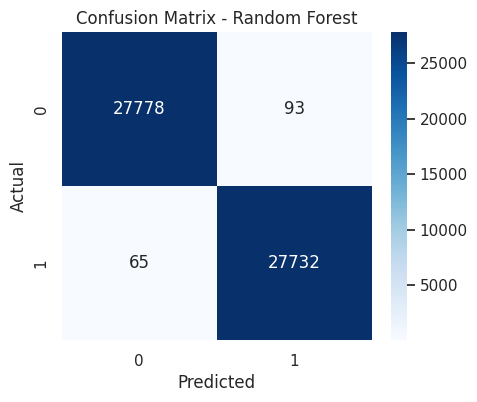


SVM
Accuracy: 0.9802938851764029
              precision    recall  f1-score   support

      attack       0.98      0.98      0.98     27871
      normal       0.98      0.98      0.98     27797

    accuracy                           0.98     55668
   macro avg       0.98      0.98      0.98     55668
weighted avg       0.98      0.98      0.98     55668



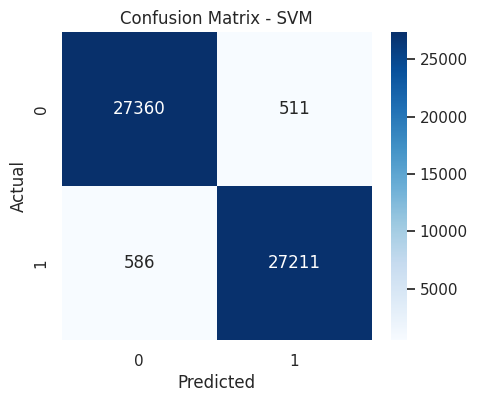


KNN
Accuracy: 0.9906589063735001
              precision    recall  f1-score   support

      attack       0.99      0.99      0.99     27871
      normal       0.99      0.99      0.99     27797

    accuracy                           0.99     55668
   macro avg       0.99      0.99      0.99     55668
weighted avg       0.99      0.99      0.99     55668



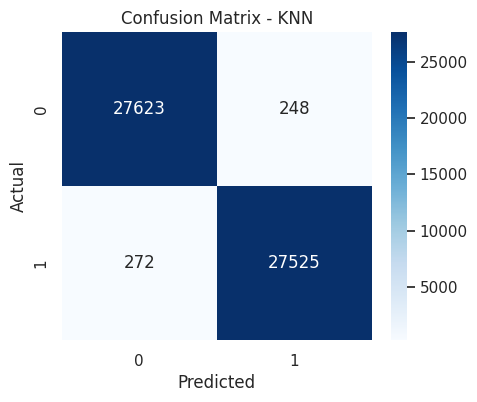

In [30]:
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

model_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    model_results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


### STEP 7: Compare Supervised Model Performance

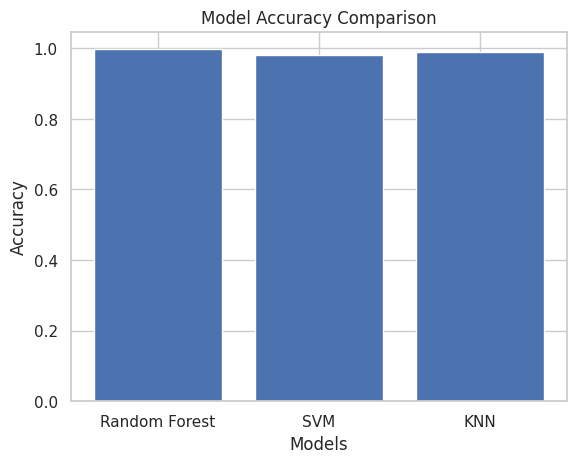

In [31]:
plt.figure()
plt.bar(model_results.keys(), model_results.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

### STEP 8: Unsupervised Learning — Isolation Forest

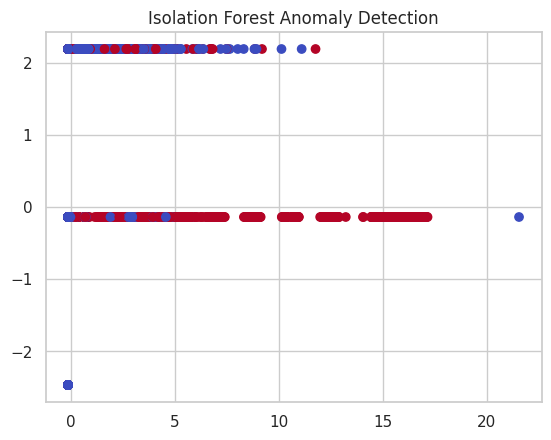

In [32]:
iso = IsolationForest(contamination=0.1)
iso.fit(X_train)

iso_pred = iso.predict(X_test)
iso_pred = np.where(iso_pred == -1, 1, 0)

# Visualization
plt.figure()
plt.scatter(X_test[:,0], X_test[:,1], c=iso_pred, cmap='coolwarm')
plt.title("Isolation Forest Anomaly Detection")
plt.show()


### STEP 10: Feature Importance (Random Forest)

                   Feature  Importance
4                src_bytes    0.175425
5                dst_bytes    0.103436
11               logged_in    0.067523
3                     flag    0.066651
29           diff_srv_rate    0.061377
28           same_srv_rate    0.057848
33  dst_host_same_srv_rate    0.055417
34  dst_host_diff_srv_rate    0.044945
2                  service    0.038552
1            protocol_type    0.036803


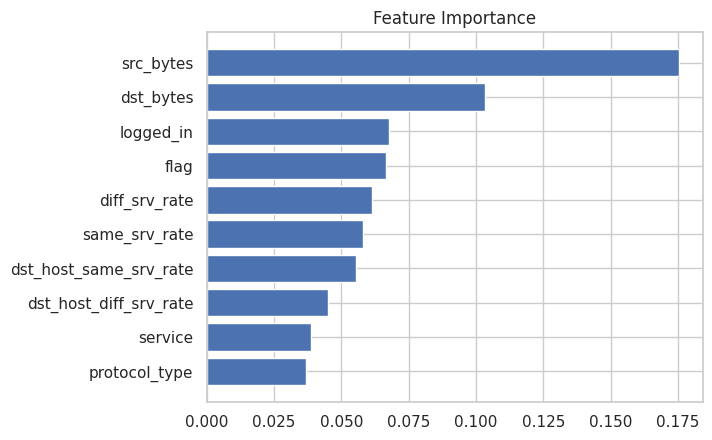

In [33]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

plt.figure()
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()


### STEP 11: PCA Visualization (2D)

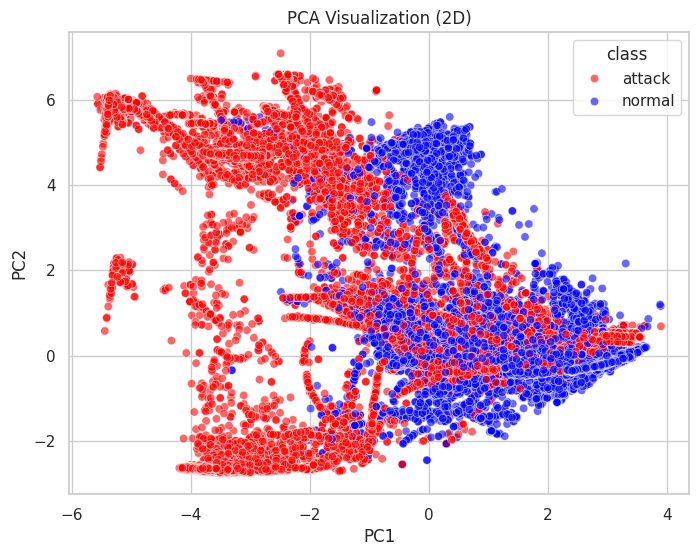

In [39]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train,
                palette={'normal': 'blue', 'attack': 'red'}, alpha=0.6)
plt.title("PCA Visualization (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Step 12: ROC Curve (Random Forest)

Classes: ['attack' 'normal']


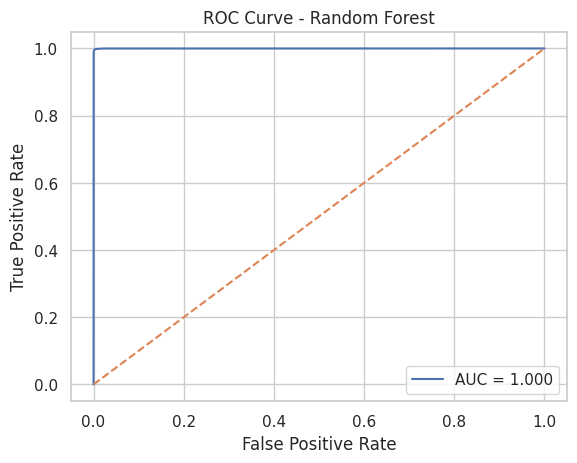

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

# Convert labels
y_test_binary = y_test.apply(lambda x: 1 if x != 'normal' else 0)

# Check class order
print("Classes:", rf_model.classes_)

# Use correct probability
y_prob = rf_model.predict_proba(X_test)[:, 0]

fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
roc_auc = roc_auc_score(y_test_binary, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


### STEP 13: Summary

In [41]:
print("\n===== PROJECT SUMMARY =====")

for name, acc in model_results.items():
    print(f"{name} Accuracy: {acc:.4f}")

print(f"\nBest Model: {max(model_results, key=model_results.get)}")
print(f"ROC AUC Score (RF): {roc_auc:.4f}")



===== PROJECT SUMMARY =====
Random Forest Accuracy: 0.9972
SVM Accuracy: 0.9803
KNN Accuracy: 0.9907

Best Model: Random Forest
ROC AUC Score (RF): 0.9999
